# Women's e-commerce clothing reviews

In the vast and diverse world of women's fashion, understanding the voices of customers is not just a luxury but a necessity. The ever-evolving landscape of e-commerce clothing demands an innovative approach to harness the valuable insights hidden within customer reviews. In this machine learning project, we embark on a journey to delve into women's e-commerce clothing customer reviews, deciphering the fine nuances of both positive and negative feedback.

The e-commerce clothing industry has undergone a significant transformation, offering an extensive array of fashion choices for women of all styles and preferences. However, as the selection grows, so does the importance of customer reviews in making informed decisions. Customers share their experiences, both positive and negative, to guide others and express their satisfaction or concerns with products. Our project aims to extract meaningful information from this treasure trove of reviews.

Our machine learning project using Naive bayes, aims to empower shoppers with informed purchasing decisions while providing e-commerce businesses with actionable feedback to enhance product quality, marketing strategies, and customer satisfaction.

In [17]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt


**1. Data understanding: loading and exploring dataset**

In [16]:

df = pd.read_csv('Womens Clothing E-Commerce Reviews.csv',nrows=1000)

pd.set_option('display.max_columns',11)
pd.set_option('display.max_colwidth',None)
display(df)

print(df.shape)

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comfortable,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,"Love this dress! it's sooo pretty. i happened to find it in a store, and i'm glad i did bc i never would have ordered it online bc it's petite. i bought a petite and am 5'8"". i love the length on me- hits just a little below the knee. would definitely be a true midi on someone who is truly petite.",5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,"I had such high hopes for this dress and really wanted it to work for me. i initially ordered the petite small (my usual size) but i found this to be outrageously small. so small in fact that i could not zip it up! i reordered it in petite medium, which was just ok. overall, the top half was comfortable and fit nicely, but the bottom half had a very tight under layer and several somewhat cheap (net) over layers. imo, a major design flaw was the net over layer sewn directly into the zipper - it c",3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, flirty, and fabulous! every time i wear it, i get nothing but great compliments!",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to the adjustable front tie. it is the perfect length to wear with leggings and it is sleeveless so it pairs well with any cardigan. love this shirt!!!,5,1,6,General,Tops,Blouses
5,5,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is not for the very petite. i am just under 5 feet tall and usually wear a 0p in this brand. this dress was very pretty out of the package but its a lot of dress. the skirt is long and very full so it overwhelmed my small frame. not a stranger to alterations, shortening and narrowing the skirt would take away from the embellishment of the garment. i love the color and the idea of the style but it just did not work on me. i returned this dress.",2,0,4,General,Dresses,Dresses
6,6,858,39,Cagrcoal shimmer fun,"I aded this in my basket at hte last mintue to see what it would look like in person. (store pick up). i went with teh darkler color only because i am so pale :-) hte color is really gorgeous, and turns out it mathced everythiing i was trying on with it prefectly. it is a little baggy on me and hte xs is hte msallet size (bummer, no petite). i decided to jkeep it though, because as i said, it matvehd everything. my ejans, pants, and the 3 skirts i waas trying on (of which i ]kept all ) oops.",5,1,1,General Petite,Tops,Knits
7,7,858,39,"Shimmer, surprisingly goes with lots","I ordered this in carbon for store pick up, and had a ton of stuff (as always) to try on and used this top to pair (skirts and pants). everything went with it. the color is really nice charcoal with shimmer, and went well with pencil skirts, flare pants, etc. my only compaint is it is a bit big, sleeves are long and it doesn't go in petite. also a bit loose for me, but no xxs... so i kept it and wil ldecide later since the light color is already sold out in hte smallest size...",4,1,4,General Petite,Tops,Knits
8,8,1077,24,Flattering,I love this dress. i usually get an xs but it runs a little snug in bust so i ordered up a size. very flattering and feminine with the usual retailer flair for style.,5,1,0,General,Dresses,Dresses
9,9,1077,34,Such a fun dress!,"I'm 5""5' and 125 lbs. i ordered the s petite to make sure the length wasn't too long. i typically wear an xs regular in retailer dresses. if you're less busty (34b cup or smaller), a s petite will fit you perfectly (snug, but not tight). i love that i could dress it up for a party, or down for work. i love that the tulle is longer then the fabric underneath.",5,1,0,General,Dresses,Dresses


(1000, 11)


In [11]:
#select 'review Text' as an intended feature and 'Recommended IND' as a target or output variable to construct new data frame.

new_df = df[['Review Text','Recommended IND']]

display(new_df.head())
print('**checking missing values from each column of a new dataframe:** \n',new_df.isnull().sum(),'\n')
print('**checking NaN values from each column of a new dataframe:** \n',new_df.isna().sum())

,Review Text,Recommended IND
0,Absolutely wonderful - silky and sexy and comfortable,1
1,"Love this dress! it's sooo pretty. i happened to find it in a store, and i'm glad i did bc i never would have ordered it online bc it's petite. i bought a petite and am 5'8"". i love the length on me- hits just a little below the knee. would definitely be a true midi on someone who is truly petite.",1
2,"I had such high hopes for this dress and really wanted it to work for me. i initially ordered the petite small (my usual size) but i found this to be outrageously small. so small in fact that i could not zip it up! i reordered it in petite medium, which was just ok. overall, the top half was comfortable and fit nicely, but the bottom half had a very tight under layer and several somewhat cheap (net) over layers. imo, a major design flaw was the net over layer sewn directly into the zipper - it c",0
3,"I love, love, love this jumpsuit. it's fun, flirty, and fabulous! every time i wear it, i get nothing but great compliments!",1
4,This shirt is very flattering to all due to the adjustable front tie. it is the perfect length to wear with leggings and it is sleeveless so it pairs well with any cardigan. love this shirt!!!,1


**checking missing values from each column of a new dataframe:** 
 Review Text        42
Recommended IND     0
dtype: int64 

**checking NaN values from each column of a new dataframe:** 
 Review Text        42
Recommended IND     0
dtype: int64


**2. Data Preprocessing: Prepare the data modelling by handling missing values and handling class imbalance**

In [5]:
#dropping as column with misssing values from our new dataframe
processed_df=new_df.dropna()
display(processed_df)

,Review Text,Recommended IND
0,Absolutely wonderful - silky and sexy and comfortable,1
1,"Love this dress! it's sooo pretty. i happened to find it in a store, and i'm glad i did bc i never would have ordered it online bc it's petite. i bought a petite and am 5'8"". i love the length on me- hits just a little below the knee. would definitely be a true midi on someone who is truly petite.",1
2,"I had such high hopes for this dress and really wanted it to work for me. i initially ordered the petite small (my usual size) but i found this to be outrageously small. so small in fact that i could not zip it up! i reordered it in petite medium, which was just ok. overall, the top half was comfortable and fit nicely, but the bottom half had a very tight under layer and several somewhat cheap (net) over layers. imo, a major design flaw was the net over layer sewn directly into the zipper - it c",0
3,"I love, love, love this jumpsuit. it's fun, flirty, and fabulous! every time i wear it, i get nothing but great compliments!",1
4,This shirt is very flattering to all due to the adjustable front tie. it is the perfect length to wear with leggings and it is sleeveless so it pairs well with any cardigan. love this shirt!!!,1
5,"I love tracy reese dresses, but this one is not for the very petite. i am just under 5 feet tall and usually wear a 0p in this brand. this dress was very pretty out of the package but its a lot of dress. the skirt is long and very full so it overwhelmed my small frame. not a stranger to alterations, shortening and narrowing the skirt would take away from the embellishment of the garment. i love the color and the idea of the style but it just did not work on me. i returned this dress.",0
6,"I aded this in my basket at hte last mintue to see what it would look like in person. (store pick up). i went with teh darkler color only because i am so pale :-) hte color is really gorgeous, and turns out it mathced everythiing i was trying on with it prefectly. it is a little baggy on me and hte xs is hte msallet size (bummer, no petite). i decided to jkeep it though, because as i said, it matvehd everything. my ejans, pants, and the 3 skirts i waas trying on (of which i ]kept all ) oops.",1
7,"I ordered this in carbon for store pick up, and had a ton of stuff (as always) to try on and used this top to pair (skirts and pants). everything went with it. the color is really nice charcoal with shimmer, and went well with pencil skirts, flare pants, etc. my only compaint is it is a bit big, sleeves are long and it doesn't go in petite. also a bit loose for me, but no xxs... so i kept it and wil ldecide later since the light color is already sold out in hte smallest size...",1
8,I love this dress. i usually get an xs but it runs a little snug in bust so i ordered up a size. very flattering and feminine with the usual retailer flair for style.,1
9,"I'm 5""5' and 125 lbs. i ordered the s petite to make sure the length wasn't too long. i typically wear an xs regular in retailer dresses. if you're less busty (34b cup or smaller), a s petite will fit you perfectly (snug, but not tight). i love that i could dress it up for a party, or down for work. i love that the tulle is longer then the fabric underneath.",1


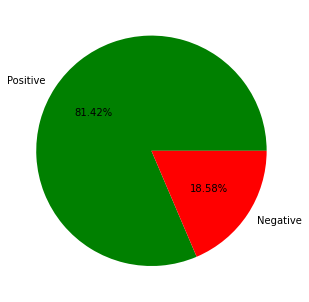

{1: 780, 0: 178}


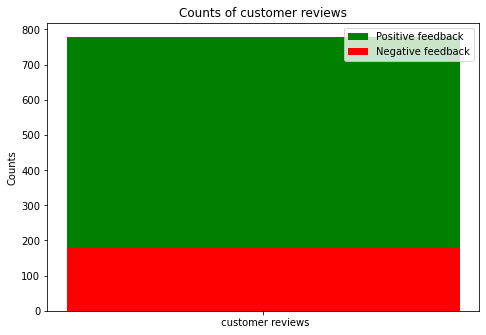

In [6]:
#Checking class imbalance

#Pie Chart
approval_counts = []

yes_count = 0
no_count = 0
for count in np.array(processed_df['Recommended IND']):
    if count==1.0:
        yes_count+=1
        
approval_counts.append(yes_count)
            
for count in np.array(processed_df['Recommended IND']):
        if count==0.0:
            no_count+=1
approval_counts.append(no_count)

fig= plt.figure()
ax=fig.add_axes([0,0,1,1])
loan_approval_label=['Positive','Negative']
colors=['green','red']
ax.pie(approval_counts,labels= loan_approval_label, colors= colors,autopct='%1.2f%%' )
plt.show()

#Bar Graph

approval_counts= (processed_df['Recommended IND'].value_counts()).to_dict()
print(approval_counts)
fig=plt.figure()
ax=fig.add_axes([0,0,1,1])
ax.bar([' customer reviews'],approval_counts[1], color='g', label='Positive feedback')
ax.bar([' customer reviews'],approval_counts[0], color='r', label='Negative feedback')
ax.set_ylabel('Counts')
ax.set_title('Counts of customer reviews')
ax.legend()
plt.show()

**3. Model Training: Split the dataset into training and testing sets**

In [7]:
review_text=list(processed_df['Review Text'])
target = list(processed_df['Recommended IND'])

review_text_train, review_text_test, target_train, target_test= train_test_split(review_text,target, test_size=0.2, random_state=42)


#vectorise training set as feature vector
vectorizer = CountVectorizer()
X= vectorizer.fit_transform(review_text_train)

#fit the training set into a model
naive_model= MultinomialNB()
naive_model.fit(X,target_train)


MultinomialNB()

**4. Model Evaluation: Evaluating the performance of the trained model using appropriate evaluation metrics, i.e accuracy, precision, recall and f1 score**

In [8]:
#evaluating

X_new= vectorizer.transform(review_text_test)
review_pred= naive_model.predict(X_new)

accuracy = accuracy_score(target_test,review_pred)
precision = precision_score(target_test,review_pred)
recall = recall_score(target_test,review_pred)
f1 = f1_score(target_test,review_pred)

print('The accuracy score is: ',accuracy)
print('The precisioon score is: ',precision)
print('The recall score is: ',recall)
print('The f1 score is: ',f1 )
print('_____________________________________________________________________________________________________________________\n')

for review, prediction in zip(review_text_test,review_pred):
    print(f'Review Text: {review} \n ')
    if prediction==1:
        print('**This is a POSITIVE review**')
    else:
        print('**This is a NEGATIVE review**')
    print()

The accuracy score is:  0.859375
The precisioon score is:  0.8571428571428571
The recall score is:  0.9936305732484076
The f1 score is:  0.9203539823008849
_____________________________________________________________________________________________________________________

Review Text: This dress is most definitely not a maxi! barely goes below the knees. also you do not get the cute detail shown on bodice. there are no folds which were an added plus on picture. waist is higher, not at natural waist. very pretty silk though and still cute. just not as pictured. 
 
**This is a POSITIVE review**

Review Text: This top is so pretty and feminine. the different floral patterns work very well together and add an interesting flare to this unique blouse. the fit is very comfortable yet still very flattering due to the empire waist and flared sleeves. the fit is true to size, i usually wear a size medium or 10 in retailer tops and the size 10 fit quite nicely. this top is a great addition to a